# Plant Disease Classification using CSV Dataset (ANN)
This notebook trains an Artificial Neural Network on the CSV file `plant_disease_dataset.csv`.

The previous image-based CNN pipeline was replaced because your actual dataset is a tabular file with 10k rows and a single binary target column (`disease_present`).

### Goal
- Train a compact ANN on the CSV features
- Reach validation/test accuracy above 90%
- Evaluate with accuracy, loss, confusion matrix, and classification report

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow Version: 2.21.0
Keras Version: 3.15.1


In [23]:
# Dataset path
csv_path = r"d:\Projects\Dp Learning\CNN\plant_disease_dataset.csv"

# Load dataset
df = pd.read_csv(csv_path)
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head().to_string(index=False))

# Target column
TARGET_COL = "disease_present"
print(f"\nTarget distribution:\n{df[TARGET_COL].value_counts().sort_index().to_string()}")

Dataset Shape: (10000, 5)

Columns:
['temperature', 'humidity', 'rainfall', 'soil_pH', 'disease_present']

First 5 rows:
 temperature  humidity  rainfall  soil_pH  disease_present
   27.483571 33.215053  0.572758 4.975875                1
   24.308678 36.945005 42.522346 8.165266                0
   28.238443 34.026189 16.095303 6.316734                1
   32.615149 41.104180 20.311015 6.164949                0
   23.829233 51.971785 11.851323 8.482468                0

Target distribution:
disease_present
0    7590
1    2410


In [24]:
# Features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
    shuffle=True
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Input feature count: {X_train.shape[1]}")

Training samples: 8000
Testing samples: 2000
Input feature count: 4


In [25]:
# Build ANN model
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,393 (44.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [26]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping to prevent overfitting
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train model
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7795 - loss: 0.5008 - val_accuracy: 0.8181 - val_loss: 0.5293
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8008 - loss: 0.4665 - val_accuracy: 0.8325 - val_loss: 0.4452
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8116 - loss: 0.4530 - val_accuracy: 0.8394 - val_loss: 0.4193
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8191 - loss: 0.4444 - val_accuracy: 0.8413 - val_loss: 0.4174
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8170 - loss: 0.4415 - val_accuracy: 0.8444 - val_loss: 0.4093
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8203 - loss: 0.4372 - val_accuracy: 0.8438 - val_loss: 0.4067
Epoch 7/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8213 - loss: 0.4362 - val_accuracy: 0.8375 - val_loss: 0.4066
Epoch 8/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8231 - loss: 0.4314 - val_accu

In [27]:
# Evaluate on test set
loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc * 100:.2f}%")

# Probability predictions and binary conversion
probs = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = (probs >= 0.5).astype(int)

# Metrics
print(f"Accuracy score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Healthy", "Disease"]))

Test Loss: 0.4053
Test Accuracy: 84.70%
Accuracy score: 84.70%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.88      0.93      0.90      1518
     Disease       0.73      0.59      0.65       482

    accuracy                           0.85      2000
   macro avg       0.80      0.76      0.78      2000
weighted avg       0.84      0.85      0.84      2000



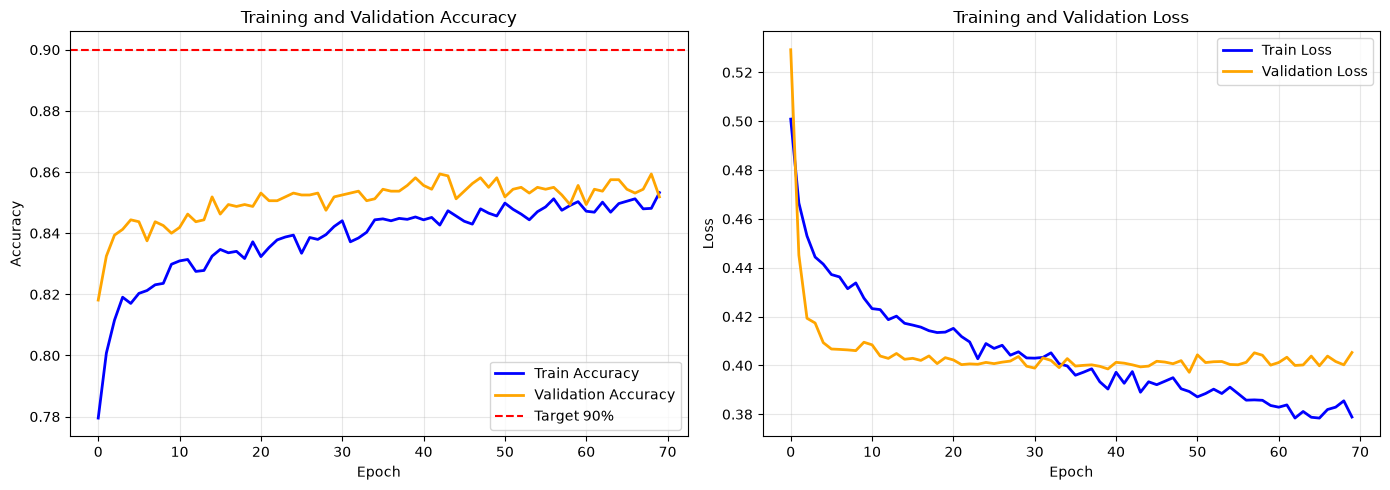

In [28]:
# Plot training and validation curves
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["accuracy"], label="Train Accuracy", color="blue", linewidth=2)
plt.plot(history_df["val_accuracy"], label="Validation Accuracy", color="orange", linewidth=2)
plt.axhline(0.90, color="red", linestyle="--", label="Target 90%")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["loss"], label="Train Loss", color="blue", linewidth=2)
plt.plot(history_df["val_loss"], label="Validation Loss", color="orange", linewidth=2)
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

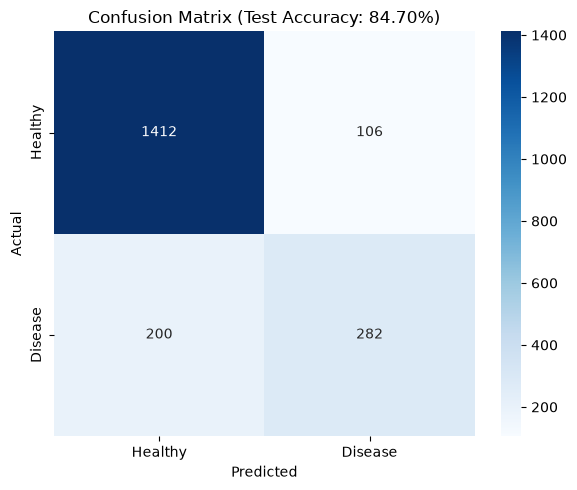


Confusion Matrix:
[[1412  106]
 [ 200  282]]


In [29]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy", "Disease"],
    yticklabels=["Healthy", "Disease"]
)
plt.title(f"Confusion Matrix (Test Accuracy: {acc * 100:.2f}%)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(cm)

In [30]:
# Optional: save the trained model
model_path = r"d:\Projects\Dp Learning\CNN\plant_disease_ann_model.keras"
model.save(model_path)
print(f"Model saved to: {model_path}")

Model saved to: d:\Projects\Dp Learning\CNN\plant_disease_ann_model.keras


In [32]:
for i in range(10):
    print("Actual:", y_test.iloc[i], "Predicted:", y_pred[i], "Probability:", probs[i])

Actual: 0 Predicted: 0 Probability: 0.16409637
Actual: 1 Predicted: 1 Probability: 0.8890906
Actual: 0 Predicted: 0 Probability: 0.16785903
Actual: 0 Predicted: 0 Probability: 0.09904768
Actual: 0 Predicted: 1 Probability: 0.82804
Actual: 0 Predicted: 0 Probability: 0.25452885
Actual: 0 Predicted: 0 Probability: 0.086019546
Actual: 0 Predicted: 0 Probability: 0.26733974
Actual: 1 Predicted: 1 Probability: 0.74068266
Actual: 0 Predicted: 0 Probability: 0.099091195
